# Eksperimen Deteksi Flaky Test: Cross-Project Flakiness Prediction

Notebook ini memakai dataset asli FlakeFlagger dari:
- `../test_features.csv`
- `../test_results.csv`

Eksperimen yang dilakukan:
1. **Dataset**: FlakeFlagger features, target `flaky`, group `project`.
2. **Model**: Random Forest dan XGBoost.
3. **Penanganan Imbalance**: `class_weight='balanced'`, `scale_pos_weight`, SMOTE, Random Undersampling.
4. **Evaluasi Cross-Project**: Leave-One-Project-Out (satu project sebagai test, project lain sebagai train).
5. **Thresholding**: threshold dicari di validation set, bukan di test set.
6. **Metrik**: Precision, Recall, F1, Average Precision/PR-AUC, Balanced Accuracy, MCC, dan Confusion Matrix.


In [11]:
# Jika package belum tersedia, jalankan cell ini sekali saja.
# Setelah selesai install, restart kernel lalu Run All.
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    matthews_corrcoef,
    roc_auc_score,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42


## 1. Load Dataset Asli FlakeFlagger


In [13]:
features_path = '../test_features.csv'
results_path = '../test_results.csv'

df_features = pd.read_csv(features_path)
df_results = pd.read_csv(results_path)

print('Shape test_features:', df_features.shape)
print('Shape test_results :', df_results.shape)
print('\nKolom test_features:')
print(df_features.columns.tolist())

print('\nDistribusi label flaky:')
print(df_features['flaky'].value_counts())

print('\nJumlah project:', df_features['project'].nunique())
print(df_features['project'].value_counts())

display(df_features.head())


Shape test_features: (22236, 29)
Shape test_results : (22245, 8)

Kolom test_features:
['Unnamed: 0', 'test_name', 'project', 'testClassName', 'testMethodName', 'flaky', 'assertion-roulette', 'conditional-test-logic', 'eager-test', 'fire-and-forget', 'indirect-testing', 'mystery-guest', 'resource-optimism', 'test-run-war', 'testLength', 'numAsserts', 'numCoveredLines', 'ExecutionTime', 'projectSourceLinesCovered', 'projectSourceClassesCovered', 'hIndexModificationsPerCoveredLine_window5', 'hIndexModificationsPerCoveredLine_window10', 'hIndexModificationsPerCoveredLine_window25', 'hIndexModificationsPerCoveredLine_window50', 'hIndexModificationsPerCoveredLine_window75', 'hIndexModificationsPerCoveredLine_window100', 'hIndexModificationsPerCoveredLine_window500', 'hIndexModificationsPerCoveredLine_window10000', 'num_third_party_libs']

Distribusi label flaky:
flaky
0    21425
1      811
Name: count, dtype: int64

Jumlah project: 24
project
assertj-core        6261
incubator-dubbo     217

,Unnamed: 0,test_name,project,testClassName,testMethodName,flaky,assertion-roulette,conditional-test-logic,eager-test,fire-and-forget,...,projectSourceClassesCovered,hIndexModificationsPerCoveredLine_window5,hIndexModificationsPerCoveredLine_window10,hIndexModificationsPerCoveredLine_window25,hIndexModificationsPerCoveredLine_window50,hIndexModificationsPerCoveredLine_window75,hIndexModificationsPerCoveredLine_window100,hIndexModificationsPerCoveredLine_window500,hIndexModificationsPerCoveredLine_window10000,num_third_party_libs
0,45,ch.qos.logback.classic.asyncappendertest.event...,logback,ch.qos.logback.classic.AsyncAppenderTest,eventWasPreparedForDeferredProcessing,0,1,0,0,0,...,12,0,0,0,0,0,0,1,3,2
1,46,ch.qos.logback.classic.asyncappendertest.setti...,logback,ch.qos.logback.classic.AsyncAppenderTest,settingIncludeCallerDataPropertyCausedCallerDa...,0,1,0,0,0,...,11,0,0,0,0,0,0,1,3,0
2,47,ch.qos.logback.classic.boolex.geventevaluatort...,logback,ch.qos.logback.classic.boolex.GEventEvaluatorTest,callerData,0,0,0,0,0,...,9,0,0,0,0,0,0,1,2,0
3,48,ch.qos.logback.classic.boolex.geventevaluatort...,logback,ch.qos.logback.classic.boolex.GEventEvaluatorTest,event,0,0,0,0,0,...,8,0,0,0,0,0,0,1,2,0
4,49,ch.qos.logback.classic.boolex.geventevaluatort...,logback,ch.qos.logback.classic.boolex.GEventEvaluatorTest,level,0,0,0,0,0,...,10,0,0,0,0,0,0,1,3,0


## 2. Preprocessing


In [14]:
# Label target dan group cross-project
y = df_features['flaky'].astype(int)
groups = df_features['project'].astype(str)

# Kolom non-feature: identifier/text/label/group
non_feature_cols = [
    'Unnamed: 0',
    'test_name',
    'project',
    'testClassName',
    'testMethodName',
    'flaky',
]

X = df_features.drop(columns=non_feature_cols, errors='ignore')

# Untuk eksperimen awal, gunakan fitur numerik saja.
X = X.select_dtypes(include=[np.number])

# Bersihkan nilai inf dan missing
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print('Jumlah sample:', X.shape[0])
print('Jumlah fitur :', X.shape[1])
print('Fitur yang dipakai:')
print(X.columns.tolist())
print('\nDistribusi label:')
print(y.value_counts())
print('\nJumlah project:', groups.nunique())


Jumlah sample: 22236
Jumlah fitur : 23
Fitur yang dipakai:
['assertion-roulette', 'conditional-test-logic', 'eager-test', 'fire-and-forget', 'indirect-testing', 'mystery-guest', 'resource-optimism', 'test-run-war', 'testLength', 'numAsserts', 'numCoveredLines', 'ExecutionTime', 'projectSourceLinesCovered', 'projectSourceClassesCovered', 'hIndexModificationsPerCoveredLine_window5', 'hIndexModificationsPerCoveredLine_window10', 'hIndexModificationsPerCoveredLine_window25', 'hIndexModificationsPerCoveredLine_window50', 'hIndexModificationsPerCoveredLine_window75', 'hIndexModificationsPerCoveredLine_window100', 'hIndexModificationsPerCoveredLine_window500', 'hIndexModificationsPerCoveredLine_window10000', 'num_third_party_libs']

Distribusi label:
flaky
0    21425
1      811
Name: count, dtype: int64

Jumlah project: 24


## 3. Fungsi Threshold, Model, dan Evaluasi


In [15]:
def find_optimal_threshold(y_true, y_probs, strategy='max_f1', target_recall=0.80):
    """Cari threshold dari validation set, bukan dari test set."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    if len(thresholds) == 0:
        return 0.5
    
    if strategy == 'max_f1':
        p = precisions[:-1]
        r = recalls[:-1]
        f1_scores = (2 * p * r) / (p + r + 1e-10)
        best_idx = int(np.argmax(f1_scores))
        return float(thresholds[best_idx])
    
    if strategy == 'target_recall':
        valid_idx = np.where(recalls[:-1] >= target_recall)[0]
        if len(valid_idx) == 0:
            return 0.5
        best_idx = int(valid_idx[-1])
        return float(thresholds[best_idx])
    
    return 0.5


def build_models(y_train):
    from sklearn.model_selection import RandomizedSearchCV
    import numpy as np
    
    neg = int(np.sum(y_train == 0))
    pos = int(np.sum(y_train == 1))
    ratio = neg / max(pos, 1)
    
    # Distribusi parameter untuk mencari bobot terbaik
    param_grid = {
        'scale_pos_weight': [1, ratio * 0.5, ratio, ratio * 1.5, ratio * 2],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 6]
    }
    
    xgb_base = XGBClassifier(
        n_estimators=100, # Menggunakan 100 pohon agar tuning tidak terlalu lama
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1
    )
    
    # Hyperparameter tuning menggunakan RandomizedSearchCV
    xgb_tuned = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_grid,
        n_iter=5, # Coba 5 kombinasi hiperparameter
        scoring='f1',
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    return {
        'RF_Baseline': RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'RF_Balanced': RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'RF_SMOTE': ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
            ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        'XGB_ClassWeight_Tuned': xgb_tuned,
        'XGB_RUS': ImbPipeline([
            ('rus', RandomUnderSampler(random_state=RANDOM_STATE)),
            ('xgb', XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                eval_metric='logloss',
                n_jobs=-1
            ))
        ]),
    }


def safe_roc_auc(y_true, y_probs):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_probs)


## 4. Cross-Project Evaluation: Leave-One-Project-Out


In [16]:
all_results = []
confusion_records = []

unique_projects = sorted(groups.unique())

for target_project in unique_projects:
    test_mask = groups == target_project
    train_mask = groups != target_project
    
    X_train_full = X.loc[train_mask].reset_index(drop=True)
    y_train_full = y.loc[train_mask].reset_index(drop=True)
    X_test = X.loc[test_mask].reset_index(drop=True)
    y_test = y.loc[test_mask].reset_index(drop=True)
    
    # Untuk metrik klasifikasi yang bermakna, test project harus punya dua kelas.
    if y_test.nunique() < 2:
        print(f'SKIP {target_project}: test project hanya punya satu kelas {y_test.unique().tolist()}')
        continue
    
    # Training juga harus punya dua kelas.
    if y_train_full.nunique() < 2:
        print(f'SKIP {target_project}: training hanya punya satu kelas')
        continue
    
    # Validation dari training projects untuk threshold tuning.
    # Threshold tidak boleh dicari di test project.
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        stratify=y_train_full,
        random_state=RANDOM_STATE
    )
    
    models = build_models(y_train)
    
    for model_name, model in models.items():
        try:
            model.fit(X_train, y_train)
            
            y_val_probs = model.predict_proba(X_val)[:, 1]
            best_thresh = find_optimal_threshold(y_val, y_val_probs, strategy='max_f1')
            
            y_test_probs = model.predict_proba(X_test)[:, 1]
            y_pred = (y_test_probs >= best_thresh).astype(int)
            
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            
            all_results.append({
                'Target Project': target_project,
                'Model': model_name,
                'Threshold': round(best_thresh, 4),
                'Test Size': int(len(y_test)),
                'Flaky in Test': int(y_test.sum()),
                'Non-Flaky in Test': int((y_test == 0).sum()),
                'Average Precision / PR-AUC': average_precision_score(y_test, y_test_probs),
                'ROC-AUC': safe_roc_auc(y_test, y_test_probs),
                'Precision (Flaky)': precision_score(y_test, y_pred, zero_division=0),
                'Recall (Flaky)': recall_score(y_test, y_pred, zero_division=0),
                'F1 (Flaky)': f1_score(y_test, y_pred, zero_division=0),
                'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
                'MCC': matthews_corrcoef(y_test, y_pred),
                'TN': int(tn),
                'FP': int(fp),
                'FN': int(fn),
                'TP': int(tp),
            })
            
            confusion_records.append({
                'Target Project': target_project,
                'Model': model_name,
                'TN': int(tn),
                'FP': int(fp),
                'FN': int(fn),
                'TP': int(tp),
            })
            
        except Exception as e:
            print(f'ERROR {target_project} - {model_name}: {e}')

# Buat dataframe hasil
if len(all_results) == 0:
    raise RuntimeError('Tidak ada hasil evaluasi. Cek apakah tiap project target memiliki dua kelas label.')

df_results = pd.DataFrame(all_results)

display(df_results.sort_values(by=['F1 (Flaky)', 'Average Precision / PR-AUC'], ascending=False))


SKIP jimfs: test project hanya punya satu kelas [0]


,Target Project,Model,Threshold,Test Size,Flaky in Test,Non-Flaky in Test,Average Precision / PR-AUC,ROC-AUC,Precision (Flaky),Recall (Flaky),F1 (Flaky),Balanced Accuracy,MCC,TN,FP,FN,TP
29,commons-exec,XGB_RUS,0.9388,55,1,54,0.500000,0.981481,0.500000,1.000000,0.666667,0.990741,0.700529,53,1,0,1
18,ambari,XGB_ClassWeight_Tuned,0.2070,324,52,272,0.425583,0.838660,0.425743,0.826923,0.562092,0.806844,0.486318,214,58,9,43
59,httpcore,XGB_RUS,0.9133,712,22,690,0.449244,0.915580,0.444444,0.727273,0.551724,0.849144,0.551500,670,20,6,16
19,ambari,XGB_RUS,0.9197,324,52,272,0.355620,0.820206,0.383178,0.788462,0.515723,0.772907,0.426000,206,66,11,41
15,ambari,RF_Baseline,0.3100,324,52,272,0.559913,0.849441,0.414634,0.653846,0.507463,0.738688,0.403025,224,48,18,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,assertj-core,RF_Balanced,0.4450,6261,1,6260,0.000215,0.315256,0.000000,0.000000,0.000000,0.499681,-0.000320,6256,4,1,0
24,assertj-core,XGB_RUS,0.8374,6261,1,6260,0.000212,0.245847,0.000000,0.000000,0.000000,0.499441,-0.000423,6253,7,1,0
20,assertj-core,RF_Baseline,0.2950,6261,1,6260,0.000193,0.254073,0.000000,0.000000,0.000000,0.499681,-0.000320,6256,4,1,0
23,assertj-core,XGB_ClassWeight_Tuned,0.2507,6261,1,6260,0.000186,0.139457,0.000000,0.000000,0.000000,0.499760,-0.000277,6257,3,1,0


## 5. Ringkasan Hasil per Model


In [17]:
metric_cols = [
    'Average Precision / PR-AUC',
    'ROC-AUC',
    'Precision (Flaky)',
    'Recall (Flaky)',
    'F1 (Flaky)',
    'Balanced Accuracy',
    'MCC'
]

summary_mean = df_results.groupby('Model')[metric_cols].mean().sort_values(by='F1 (Flaky)', ascending=False)
summary_median = df_results.groupby('Model')[metric_cols].median().sort_values(by='F1 (Flaky)', ascending=False)
summary_std = df_results.groupby('Model')[metric_cols].std().sort_values(by='F1 (Flaky)', ascending=False)

print('Rata-rata metrik per model:')
display(summary_mean)

print('Median metrik per model:')
display(summary_median)

print('Standar deviasi metrik per model:')
display(summary_std)


Rata-rata metrik per model:


,Average Precision / PR-AUC,ROC-AUC,Precision (Flaky),Recall (Flaky),F1 (Flaky),Balanced Accuracy,MCC
Model,,,,,,,
XGB_RUS,0.202236,0.731977,0.187981,0.175479,0.103059,0.556588,0.096950
RF_Baseline,0.201956,0.711114,0.103633,0.105672,0.061831,0.525920,0.052602
XGB_ClassWeight_Tuned,0.203996,0.712330,0.129400,0.099510,0.057635,0.526099,0.050791
RF_Balanced,0.190431,0.701967,0.106821,0.054530,0.042205,0.514834,0.034892
RF_SMOTE,0.193509,0.698483,0.091282,0.078578,0.033587,0.512378,0.021644


Median metrik per model:


,Average Precision / PR-AUC,ROC-AUC,Precision (Flaky),Recall (Flaky),F1 (Flaky),Balanced Accuracy,MCC
Model,,,,,,,
XGB_RUS,0.109411,0.764095,0.014925,0.01227,0.013468,0.5,0.0
RF_Balanced,0.088944,0.754208,0.000000,0.00000,0.000000,0.5,0.0
RF_Baseline,0.091587,0.698851,0.000000,0.00000,0.000000,0.5,0.0
RF_SMOTE,0.079085,0.750471,0.000000,0.00000,0.000000,0.5,0.0
XGB_ClassWeight_Tuned,0.093087,0.754328,0.000000,0.00000,0.000000,0.5,0.0


Standar deviasi metrik per model:


,Average Precision / PR-AUC,ROC-AUC,Precision (Flaky),Recall (Flaky),F1 (Flaky),Balanced Accuracy,MCC
Model,,,,,,,
XGB_RUS,0.247499,0.181632,0.315290,0.329519,0.195161,0.131009,0.196672
XGB_ClassWeight_Tuned,0.249984,0.204191,0.298736,0.227708,0.136991,0.073678,0.132488
RF_Baseline,0.254722,0.179444,0.226498,0.236277,0.135125,0.061998,0.126403
RF_Balanced,0.241363,0.204280,0.257510,0.140666,0.108473,0.046506,0.093378
RF_SMOTE,0.240458,0.209774,0.228479,0.195661,0.081611,0.040071,0.061333


## 6. Confusion Matrix Model Terbaik


Model terbaik berdasarkan rata-rata F1 (Flaky): XGB_RUS


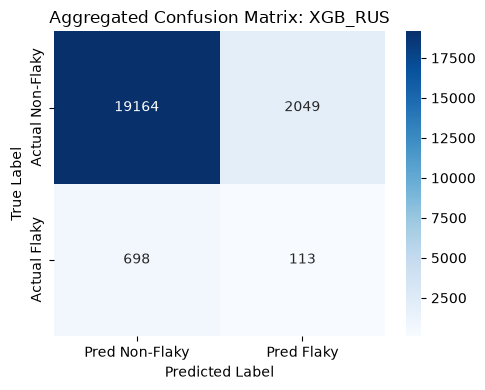

In [18]:
best_model_name = summary_mean.index[0]
print('Model terbaik berdasarkan rata-rata F1 (Flaky):', best_model_name)

best_rows = df_results[df_results['Model'] == best_model_name]
cm_total = np.array([
    [best_rows['TN'].sum(), best_rows['FP'].sum()],
    [best_rows['FN'].sum(), best_rows['TP'].sum()]
])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Non-Flaky', 'Pred Flaky'],
            yticklabels=['Actual Non-Flaky', 'Actual Flaky'])
plt.title(f'Aggregated Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


## 7. Simpan Hasil Eksperimen


In [19]:
output_path = 'hasil_cross_project_flaky_prediction.csv'
df_results.to_csv(output_path, index=False)
print('Hasil eksperimen disimpan ke:', output_path)


Hasil eksperimen disimpan ke: hasil_cross_project_flaky_prediction.csv
